In [12]:
# setting up the notebook 

import librosa 
import librosa.display 
import pywt
import pandas as pd 
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt 
import os 
from glob import glob
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import random



In [13]:
df = pd.read_csv('parkinsons.csv')
df.drop(columns=['name'], errors='ignore', inplace=True)
df = df.drop(columns=['DFA', 'RPDE', 'PPE', 'D2', 'NHR', 'HNR', 'spread1', 'spread2'])
df = df.drop(columns=['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)'])
df

,MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,status
0,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,0.02182,0.03130,0.02971,0.06545,1
1,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,0.03134,0.04518,0.04368,0.09403,1
2,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,0.02757,0.03858,0.03590,0.08270,1
3,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,0.02924,0.04005,0.03772,0.08771,1
4,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,0.03490,0.04825,0.04465,0.10470,1
...,...,...,...,...,...,...,...,...,...,...,...,...
190,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,0.405,0.02336,0.02498,0.02745,0.07008,0
191,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,0.263,0.01604,0.01657,0.01879,0.04812,0
192,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,0.256,0.01268,0.01365,0.01667,0.03804,0
193,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,0.241,0.01265,0.01321,0.01588,0.03794,0


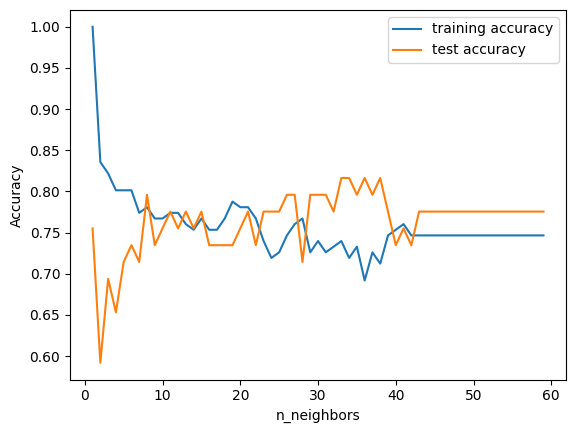

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
X_train, X_test, y_train, y_test = train_test_split(df.drop(['status'], axis=1),df['status'],
                                                    test_size=0.25,random_state=42)

training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 60) # try n_neighbors from 1 to 50

for n_neighbors in neighbors_settings:
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)  # build the model
    clf.fit(X_train, y_train)

    training_accuracy.append(clf.score(X_train, y_train)) # record training set accuracy
    test_accuracy.append(clf.score(X_test, y_test))   # record generalization accuracy

plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

pass

In [15]:
lahat_training = pd.DataFrame()
lahat_test = pd.DataFrame()
for seedN in tqdm(range(1, 50, 1)):
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(df.drop(['status'], axis=1),df['status'],
                                                    test_size=0.25,random_state=seedN)
    training_accuracy = []
    test_accuracy = []
    neighbors_settings = range(1, 50) # try n_neighbors from 1 to 50

    for n_neighbors in neighbors_settings:
        clf = KNeighborsClassifier(n_neighbors=n_neighbors)  # build the model
        clf.fit(X_train, y_train)

        training_accuracy.append(clf.score(X_train, y_train)) # record training set accuracy
        test_accuracy.append(clf.score(X_test, y_test))   # record generalization accuracy

    lahat_training[seedN] = training_accuracy
    lahat_test[seedN] = test_accuracy

100%|██████████████████████████████████████████████████████████████████████████████████| 49/49 [00:26<00:00,  1.87it/s]


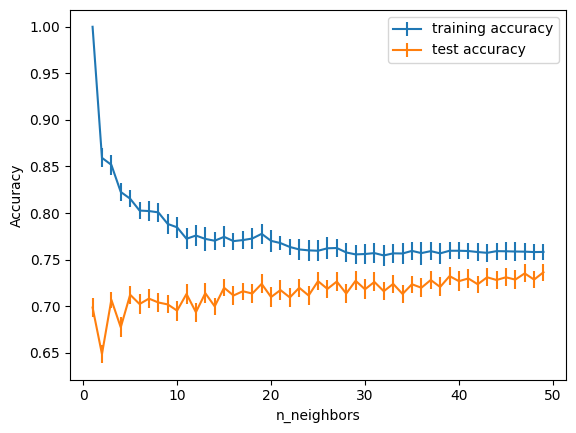

In [16]:
plt.errorbar(neighbors_settings, lahat_training.mean(axis=1),
             yerr=lahat_training.std(axis=1)/2, label="training accuracy")
plt.errorbar(neighbors_settings, lahat_test.mean(axis=1),
             yerr=lahat_test.std(axis=1)/6, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

In [19]:
'''KNN with random number of neighbors'''

# 1. Instantiate the class with a specific number of neighbors (e.g., 3)
X_train, X_test, y_train, y_test = train_test_split(df.drop(['status'], axis=1),df['status'],
                                                    test_size=0.25,random_state=11)
clf = KNeighborsClassifier(n_neighbors=19) 

# 2. Fit the model using the scaled training data
clf.fit(X_train, y_train) 

# 3. Evaluate the results
print("Train set accuracy: {:.2f}".format(clf.score(X_train, y_train)))
print("Test set accuracy: {:.2f}".format(clf.score(X_test, y_test)))

Train set accuracy: 0.76
Test set accuracy: 0.76
